In [47]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score,  recall_score, precision_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.preprocessing import MinMaxScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import BernoulliNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import StackingClassifier 

In [19]:
df = pd.read_csv('epl_final.csv')
df
x = df[[ 'FullTimeHomeGoals',
       'FullTimeAwayGoals', 'HalfTimeHomeGoals',
       'HalfTimeAwayGoals',  'HomeShots', 'AwayShots',
       'HomeShotsOnTarget', 'AwayShotsOnTarget', 'HomeCorners', 'AwayCorners',
       'HomeFouls', 'AwayFouls', 'HomeYellowCards', 'AwayYellowCards',
       'HomeRedCards', 'AwayRedCards']].values
y = df.values[:, 6]
df

,Season,MatchDate,HomeTeam,AwayTeam,FullTimeHomeGoals,FullTimeAwayGoals,FullTimeResult,HalfTimeHomeGoals,HalfTimeAwayGoals,HalfTimeResult,...,HomeShotsOnTarget,AwayShotsOnTarget,HomeCorners,AwayCorners,HomeFouls,AwayFouls,HomeYellowCards,AwayYellowCards,HomeRedCards,AwayRedCards
0,2000/01,2000-08-19,Charlton,Man City,4,0,H,2,0,H,...,14,4,6,6,13,12,1,2,0,0
1,2000/01,2000-08-19,Chelsea,West Ham,4,2,H,1,0,H,...,10,5,7,7,19,14,1,2,0,0
2,2000/01,2000-08-19,Coventry,Middlesbrough,1,3,A,1,1,D,...,3,9,8,4,15,21,5,3,1,0
3,2000/01,2000-08-19,Derby,Southampton,2,2,D,1,2,A,...,4,6,5,8,11,13,1,1,0,0
4,2000/01,2000-08-19,Leeds,Everton,2,0,H,2,0,H,...,8,6,6,4,21,20,1,3,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9375,2024/25,2025-05-04,Brentford,Man United,4,3,H,2,1,H,...,6,5,7,4,8,10,0,2,0,0
9376,2024/25,2025-05-04,Brighton,Newcastle,1,1,D,1,0,H,...,2,5,1,4,15,10,2,1,0,0
9377,2024/25,2025-05-04,West Ham,Tottenham,1,1,D,1,1,D,...,2,2,1,3,18,15,2,2,0,0
9378,2024/25,2025-05-04,Chelsea,Liverpool,3,1,H,1,0,H,...,7,2,3,6,10,11,2,2,0,0


In [ ]:
normalizador = MinMaxScaler()
x_normalizar = normalizador.fit_transform(x)

x_train,x_test, y_train, y_test = train_test_split(x_normalizar, y, test_size= 0.2, random_state= 1234)


In [25]:
nombres = SVC(), KNeighborsClassifier(), GaussianNB(), BernoulliNB()
for i in nombres:
    i.fit(x_train, y_train)
    prediccion = i.predict(x_test)
    print(accuracy_score(prediccion, y_test)*100)

99.94669509594883
77.07889125799574
73.88059701492537
73.72068230277186


Kneighbords



In [30]:
clf = KNeighborsClassifier()
params = {'n_neighbors': [5,6, 1,7, 3, 2], 'algorithm': ['ball_tree', 'brute', 'kd_tree']}
result = GridSearchCV(clf, params, cv = 5)
result.fit(x_train, y_train)
print('Exactitud: ', result.best_estimator_)
print('Precisión: ', result.best_score_)

Exactitud:  KNeighborsClassifier(algorithm='ball_tree', n_neighbors=7)
Precisión:  0.790645081057073


SVC

In [31]:
clf = SVC()
params = {'C': [1,2,3,4,5,6,7,8,9], 'kernel': ['rbf', 'linear', 'poly', 'sigmoid']}
result = GridSearchCV(clf, params, cv = 5)
result.fit(x_train, y_train)
print('Exactitud: ', result.best_estimator_)
print('Exactitud: ', result.best_score_)

Exactitud:  SVC(C=1, kernel='linear')
Exactitud:  1.0


Mezcla de ultimos algoritmos


In [35]:
algo = GaussianNB(), BernoulliNB(), DecisionTreeClassifier()
for a in algo:
    a.fit(x_train, y_train)
    prediccion = a.predict(x_test)
    print(accuracy_score(prediccion, y_test)*100)

73.88059701492537
73.72068230277186
99.7867803837953


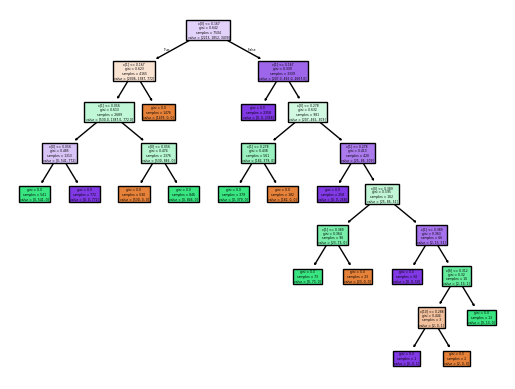

In [ ]:
fig = plot_tree(a, filled = True)
plt.show()

Esembles de distintos algoritmos 

In [40]:
rb = GaussianNB()
sv = SVC()
kn = KNeighborsClassifier()
estimadores = [('sv', sv), ('rb', rb),('kn', kn)]
clf = StackingClassifier(estimators= estimadores, final_estimator= DecisionTreeClassifier())
clf.fit(x_train, y_train)
prediccion = clf.predict(x_test)
print(accuracy_score(prediccion, y_test)*100)

99.94669509594883


In [46]:
df = pd.read_csv('Heart_failure_clinical_records_dataset.csv')
x = df.values[:,:-1]
y = df.values[:, -1]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, shuffle= True, random_state=1357)

In [50]:
clf = GaussianNB()
clf.fit(x_train, y_train)
prediccion = clf.predict(x_test)
print("Accuracy: ", accuracy_score(prediccion, y_test)*100)
print("Precisión: ", precision_score(prediccion, y_test)*100)
print("Recall: ", recall_score(prediccion, y_test)*100)
print(classification_report(y_true=y_test, y_pred= prediccion))

Accuracy:  80.0
Precisión:  42.10526315789473
Recall:  88.88888888888889
              precision    recall  f1-score   support

         0.0       0.78      0.98      0.87        41
         1.0       0.89      0.42      0.57        19

    accuracy                           0.80        60
   macro avg       0.84      0.70      0.72        60
weighted avg       0.82      0.80      0.78        60



In [ ]:
from sklearn.model_selection import cross_validate
a = DecisionTreeClassifier()
result = cross_validate(a, x, y, cv = 10, scoring = ['accuracy'])
res = result['test_accuracy']
print(np.mean(res)*100)

69.20689655172414


In [67]:
n = 1,3,5,10
pesos = ["uniform", "distance"]
mejor_n = 1
mejor_pesos = "hola"
mejor_accu = 1
for i in pesos:
    for j in n:
        clf = KNeighborsClassifier(n_neighbors= j, weights= i)
        clf.fit(x_train, y_train)
        prediccion = clf.predict(x_test)
        if accuracy_score(prediccion, y_test)*100 > mejor_accu:
            mejor_accu = accuracy_score(prediccion, y_test)*100
            mejor_n = j
            mejor_pesos = i
print(f"Exactitud {mejor_accu} para Nº vecinos {mejor_n} y para el peso {mejor_pesos}")

Exactitud 70.0 para Nº vecinos 5 y para el peso uniform


In [ ]:
clf = KNeighborsClassifier()
clf.fit(x_train, y_train)
prediccion = clf.predict(x_test)
print(accuracy_score(prediccion, y_test)*100)

70.0


In [ ]:
from sklearn.ensemble import RandomForestClassifier
params = {"n_estimators": [50, 100, 150, 200], "max_depth": [2,4,6,8,10], "max_features": [None, 'sqrt', 'log2']}
tree = RandomForestClassifier()
result = GridSearchCV(tree, params)
result.fit(x_train, y_train)
prediccion = result.predict(x_test)
print("Accuracy: ", accuracy_score(prediccion, y_test)*100)
print(result.best_estimator_)


clf = RandomForestClassifier()
clf.fit(x_train, y_train)
pred = clf.predict(x_test)
print(accuracy_score(pred, y_test))

Accuracy:  80.0
RandomForestClassifier(max_depth=2, max_features=None, n_estimators=50)
0.8534574468085108
0.8


In [77]:
#esemble
from sklearn.linear_model import LogisticRegression
nb = GaussianNB()
svm = SVC()
tr = DecisionTreeClassifier()
lr = LogisticRegression()
estimadores = [('nb', nb), ('svm', svm), ('tr', tr)]
result = StackingClassifier(estimators= estimadores, final_estimator= lr)
result.fit(x_train, y_train)
prediccion = result.predict(x_test)
print("Exactitud: ", accuracy_score(prediccion, y_test)*100)
print("Precisión: ", precision_score(prediccion, y_test)*100)
print("sensibilidad: ", recall_score(prediccion, y_test)*100)

Exactitud:  83.33333333333334
Precisión:  57.89473684210527
sensibilidad:  84.61538461538461


In [109]:
df2 = pd.read_csv('seeds_dataset.csv')
df2
x = df2.values[:,:-1]
y = df2.values[:,-1]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=1357)

In [102]:
clf = DecisionTreeClassifier()
clf.fit(x_train,y_train)
prediccion = clf.predict(x_test)
print('Exactitud: ', accuracy_score(prediccion, y_test)*100)
#print('Sensibilidad: ', recall_score(prediccion, y_test)*100)
#print('Precisión: ', precision_score(prediccion, y_test)*100)
print(classification_report(y_true= y_test, y_pred=prediccion))

Exactitud:  80.95238095238095
              precision    recall  f1-score   support

         1.0       0.89      0.53      0.67        15
         2.0       1.00      1.00      1.00        12
         3.0       0.67      0.93      0.78        15

    accuracy                           0.81        42
   macro avg       0.85      0.82      0.81        42
weighted avg       0.84      0.81      0.80        42



In [105]:
tree = DecisionTreeClassifier(random_state=1357)
result = cross_validate(tree, x,y, cv = 10, scoring= ['accuracy'])
res = result['test_accuracy']
print("Exactitud: ", np.mean(res)*100)
print(result.keys())

Exactitud:  90.42857142857143
dict_keys(['fit_time', 'score_time', 'test_accuracy'])


In [107]:
kernel = "rbf", "linear", "poly"
c_mayus = 0.1 , 1, 5, 10

for k in kernel:
    for c in c_mayus:
        clf = SVC(kernel= k, C = c)
        clf.fit(x_train, y_train)
        prediccion = clf.predict(x_test)
        print(f"Exactitud {accuracy_score(y_test, prediccion)*100} con C: {c} y Kernel: {k}")

Exactitud 64.28571428571429 con C: 0.1 y Kernel: rbf
Exactitud 88.09523809523809 con C: 1 y Kernel: rbf
Exactitud 85.71428571428571 con C: 5 y Kernel: rbf
Exactitud 85.71428571428571 con C: 10 y Kernel: rbf
Exactitud 85.71428571428571 con C: 0.1 y Kernel: linear
Exactitud 90.47619047619048 con C: 1 y Kernel: linear
Exactitud 90.47619047619048 con C: 5 y Kernel: linear
Exactitud 92.85714285714286 con C: 10 y Kernel: linear
Exactitud 83.33333333333334 con C: 0.1 y Kernel: poly
Exactitud 88.09523809523809 con C: 1 y Kernel: poly
Exactitud 85.71428571428571 con C: 5 y Kernel: poly
Exactitud 90.47619047619048 con C: 10 y Kernel: poly


Actividad resulta con datos normalizados

In [108]:
x = df2.values[:,:-1]
normalizador = MinMaxScaler()
x_normalizar = normalizador.fit_transform(x)
y = df2.values[:,-1]
x_train, x_test, y_train, y_test = train_test_split(x_normalizar, y, test_size=0.2, random_state=1357)
kernel = "rbf", "linear", "poly"
c_mayus = 0.1 , 1, 5, 10

for k in kernel:
    for c in c_mayus:
        clf = SVC(kernel= k, C = c)
        clf.fit(x_train, y_train)
        prediccion = clf.predict(x_test)
        print(f"Exactitud {accuracy_score(y_test, prediccion)*100} con C: {c} y Kernel: {k}")

Exactitud 92.85714285714286 con C: 0.1 y Kernel: rbf
Exactitud 90.47619047619048 con C: 1 y Kernel: rbf
Exactitud 88.09523809523809 con C: 5 y Kernel: rbf
Exactitud 90.47619047619048 con C: 10 y Kernel: rbf
Exactitud 85.71428571428571 con C: 0.1 y Kernel: linear
Exactitud 90.47619047619048 con C: 1 y Kernel: linear
Exactitud 92.85714285714286 con C: 5 y Kernel: linear
Exactitud 92.85714285714286 con C: 10 y Kernel: linear
Exactitud 85.71428571428571 con C: 0.1 y Kernel: poly
Exactitud 92.85714285714286 con C: 1 y Kernel: poly
Exactitud 92.85714285714286 con C: 5 y Kernel: poly
Exactitud 95.23809523809523 con C: 10 y Kernel: poly


Con los parametros por defecto

In [110]:
clf = SVC()
clf.fit(x_train, y_train)
prediccion = clf.predict(x_test)
print("Exactitud con parametros por defecto: ", accuracy_score(y_test, prediccion)*100)

Exactitud con parametros por defecto:  88.09523809523809


In [114]:
params = {'kernel': ['rbf', 'linear', 'poly'], 'C': [0.1, 1, 5, 10, 20], 'degree':[2 ,3], 'gamma': ['scale', 'auto']}
result = GridSearchCV(clf, params)
result.fit(x_train, y_train)
prediccion = result.predict(x_test)
print("Exactitud con parametros por defecto: ", accuracy_score(y_test, prediccion)*100)
print(result.best_estimator_)

Exactitud con parametros por defecto:  95.23809523809523
SVC(C=5, degree=2, gamma='auto', kernel='poly')


In [117]:
estimadores = [('tr', DecisionTreeClassifier()), ('KN', KNeighborsClassifier()), ('rd',RandomForestClassifier(n_estimators=150))]
result = StackingClassifier(estimators= estimadores, final_estimator= LogisticRegression())
result.fit(x_train, y_train)
prediccion = result.predict(x_test)
print("Exactitud : ", accuracy_score(y_test, prediccion)*100)
print(classification_report(y_pred=prediccion, y_true=y_test))

Exactitud :  85.71428571428571
              precision    recall  f1-score   support

         1.0       0.80      0.80      0.80        15
         2.0       1.00      1.00      1.00        12
         3.0       0.80      0.80      0.80        15

    accuracy                           0.86        42
   macro avg       0.87      0.87      0.87        42
weighted avg       0.86      0.86      0.86        42



In [124]:
df = pd.read_csv('Heart_failure_clinical_records_dataset.csv')
x = df.values[:,:-1]
y = df.values[:, -1]
clf = GaussianNB()
x_train, x_test, y_train,y_test = train_test_split(x, y, test_size=0.2, random_state=1357)
clf.fit(x_train, y_train)
pred = clf.predict(x_test)
print("Exactitud: ", accuracy_score(y_test, pred)*100)
print("Sensibilidad: ", recall_score(pred, y_test)*100)
print("Precision: ", precision_score(pred, y_test)*100)
print(classification_report(y_pred=pred, y_true=y_test))

Exactitud:  80.0
Sensibilidad:  88.88888888888889
Precision:  42.10526315789473
              precision    recall  f1-score   support

         0.0       0.78      0.98      0.87        41
         1.0       0.89      0.42      0.57        19

    accuracy                           0.80        60
   macro avg       0.84      0.70      0.72        60
weighted avg       0.82      0.80      0.78        60



La exactitud mide cuando cuando se equivoca nuestro clasificador

La precisión nos muestra como de bien predice las distantas muestras

la sensibilidad nos dice como clasifica las muestras 1 que 

In [126]:
clf = DecisionTreeClassifier()
result = cross_validate(clf, x, y, cv = 10, scoring='accuracy')
res = result['test_score']
print("exactitud: ", np.mean(res)*100)

exactitud:  68.19540229885057


In [128]:
neighbords = 1,3,5,10
pesos = "uniform", "distance"
mejor= 0
parametros = ()
for p in pesos:
    for n in neighbords:
        clf = KNeighborsClassifier( n_neighbors= n, weights= p)
        clf.fit(x_train, y_train)
        pred = clf.predict(x_test)
        result = accuracy_score(pred, y_test)*100
        print(f"Para {n} vecinos y {p} como peso, su resultado es de {result}")
        if result > mejor:
            mejor = result
            parametros= (n, p)
print(f"Mejor parametro {parametros}, con resultado: {mejor}")

clf = KNeighborsClassifier()
clf.fit(x_train, y_train)
pred = clf.predict(x_test)
result = accuracy_score(pred, y_test)*100
print("Exactitud por defecto es igual a: ", result)

Para 1 vecinos y uniform como peso, su resultado es de 58.333333333333336
Para 3 vecinos y uniform como peso, su resultado es de 58.333333333333336
Para 5 vecinos y uniform como peso, su resultado es de 70.0
Para 10 vecinos y uniform como peso, su resultado es de 68.33333333333333
Para 1 vecinos y distance como peso, su resultado es de 58.333333333333336
Para 3 vecinos y distance como peso, su resultado es de 56.666666666666664
Para 5 vecinos y distance como peso, su resultado es de 65.0
Para 10 vecinos y distance como peso, su resultado es de 61.66666666666667
Mejor parametro (5, 'uniform'), con resultado: 70.0
Exactitud por defecto es igual a:  70.0


In [134]:
clf = RandomForestClassifier()
params = {"n_estimators": [50,100,150,200], "max_depth": [2,4,6,8,10], "max_features": [None, "sqrt", "log2"]}
resultado = GridSearchCV(clf, params)
resultado.fit(x_train, y_train)
pred = resultado.predict(x_test)
print(accuracy_score(pred, y_test))
print(resultado.best_estimator_)

0.8
RandomForestClassifier(max_depth=2, max_features=None, n_estimators=150)


In [ ]:
clf = DecisionTreeClassifier()
resultado = cross_validate( clf, x ,y , cv = 10, scoring=['accuracy'])
res = resultado['test_accuracy']
print("Exactitud: ", np.mean(res)*100)


Exactitud:  68.88505747126436


Exactitud 58.333333333333336, Vecinos 1, pesos uniform
Exactitud 58.333333333333336, Vecinos 1, pesos distance
Exactitud 58.333333333333336, Vecinos 3, pesos uniform
Exactitud 56.666666666666664, Vecinos 3, pesos distance
Exactitud 70.0, Vecinos 5, pesos uniform
Exactitud 65.0, Vecinos 5, pesos distance
Exactitud 68.33333333333333, Vecinos 10, pesos uniform
Exactitud 61.66666666666667, Vecinos 10, pesos distance
Mejor parametro (5, 'uniform') con resultado 70.0
[[34  7]
 [16  3]]


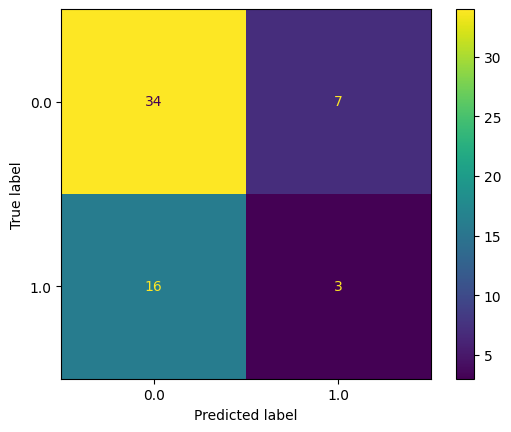

In [145]:
neighbords= [1,3,5,10]
pesos = ["uniform", "distance"]
mejor = 0
parametros = ()
for n in neighbords:
    for p in pesos:
        clf = KNeighborsClassifier(n_neighbors= n, weights= p)
        clf.fit(x_train, y_train)
        pred = clf.predict(x_test)
        resultado = accuracy_score(pred, y_test)*100
        print(f"Exactitud {resultado}, Vecinos {n}, pesos {p}")
        if mejor < resultado:
            mejor = resultado
            parametros = (n, p)
print(f"Mejor parametro {parametros} con resultado {mejor}")

cm = confusion_matrix(y_pred=pred, y_true=y_test)
print(cm)
matrix = ConfusionMatrixDisplay(cm, display_labels=clf.classes_)
matrix.plot()